# Introduction to Quantum Circuits
While circuits traditionally mean circular paths, computational circuits (quantum circuits being a special type of computational circuit) must be acyclic, sequential paths, where the flow of left to right represents time.

In [45]:
from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit.library import CXGate, SwapGate
from qiskit.quantum_info import Statevector
import numpy as np

## Single Qubit Circuits

In quantum circuits, wires represent qubits, and gates represent operations on those qubits, an example is shown below:

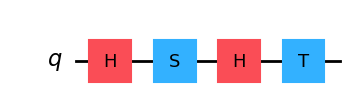

<IPython.core.display.Latex object>

After applying the circuit, we get:


<IPython.core.display.Latex object>

In [46]:
# Create a simple quantum circuit with 1 qubit
qc = QuantumCircuit(1)
qc.h(0)
qc.s(0)
qc.h(0)
qc.t(0)

display(qc.draw('mpl'))

ket0 = Statevector.from_label('0')
display(ket0.draw('latex', prefix='|0⟩ = '))

res_state = ket0.evolve(qc)
print('After applying the circuit, we get:')
display(res_state.draw('latex'))

## Circuits with 2-Qubit Gates
While any two qubit unitary operation can be used in a quantum circuit, we will provide C-NOT and SWAP gates as examples of 2-qubit gates:

### C-NOT Gate


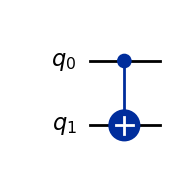

<IPython.core.display.Latex object>

After applying the C-NOT gate, we get:


<IPython.core.display.Latex object>

If we want the control qubit to be the q1 in the circuit
(left qubit in the tensor representation)
 we switch the order of the numbers in the CX gate:


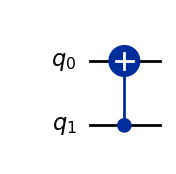

Now we get:


<IPython.core.display.Latex object>

In [47]:
cx = CXGate()
qc = QuantumCircuit(2)
qc.append(cx, [0, 1]) # first argument is the control qubit, second is the target qubit
display(qc.draw('mpl'))

c00 = 1 / np.sqrt(2)
c01 = -1 / np.sqrt(6)
c10 = 1j / np.sqrt(6)
c11 = 1 / np.sqrt(6)

phi = Statevector([c00, c01, c10, c11])
display(phi.draw('latex', prefix='|\\phi\\rangle= '))
final_state = phi.evolve(qc)
print('After applying the C-NOT gate, we get:')
display(final_state.draw('latex'))

print('If we want the control qubit to be the q1 in the circuit\n'
'(left qubit in the tensor representation)\n',
'we switch the order of the numbers in the CX gate:')
qc2 = QuantumCircuit(2)
qc2.append(cx, [1, 0])
display(qc2.draw('mpl'))

final_state2 = phi.evolve(qc2)
print('Now we get:')
display(final_state2.draw('latex'))

## Swap Gate

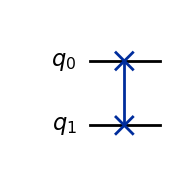

<IPython.core.display.Latex object>

After applying the SWAP gate, we get:


<IPython.core.display.Latex object>

In [48]:
swap = SwapGate()
qc = QuantumCircuit(2)
qc.append(swap, [0, 1])
display(qc.draw('mpl'))

c00 = 1 / np.sqrt(2)
c01 = -1 / np.sqrt(6)
c10 = 1j / np.sqrt(6)
c11 = 1 / np.sqrt(6)

phi = Statevector([c00, c01, c10, c11])
display(phi.draw('latex', prefix='|\\phi\\rangle= '))

final_state = phi.evolve(qc)
print('After applying the SWAP gate, we get:')
display(final_state.draw('latex'))

## Circuits with 3-qubit Gates
Similar to above, we can represent the Fredkin and Toffoli gates as 3-qubit gates in quantum circuits:

### Fredkin (CSWAP) Gate

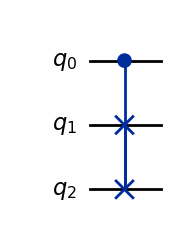

<IPython.core.display.Latex object>

After applying the CSWAP gate, we get:


<IPython.core.display.Latex object>

In [49]:
cswap = SwapGate().control()
qc = QuantumCircuit(3)
qc.append(cswap, [0, 1, 2]) # control is q0
display(qc.draw('mpl'))

c00 = 1 / np.sqrt(2)
c01 = -1 / np.sqrt(6)
c10 = 1j / np.sqrt(6)
c11 = 1 / np.sqrt(6)
psi = Statevector([0, 0, c00, c01, c10, c11, 0, 0])
display(psi.draw('latex', prefix='|\\psi\\rangle = '))

final_state = psi.evolve(qc)
print('After applying the CSWAP gate, we get:')
display(final_state.draw('latex'))

### Toffoli (CCX) Gate

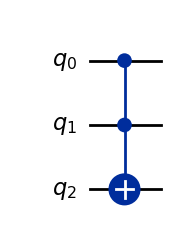

<IPython.core.display.Latex object>

After applying the CCX gate, we get:


<IPython.core.display.Latex object>

In [50]:
ccx = CXGate().control()
qc = QuantumCircuit(3)
qc.append(ccx, [0, 1, 2]) # control is q0
display(qc.draw('mpl'))

c00 = 1 / np.sqrt(2)
c01 = -1 / np.sqrt(6)
c10 = 1j / np.sqrt(6)
c11 = 1 / np.sqrt(6)
psi = Statevector([0, 0, c00, c01, c10, c11, 0, 0])
display(psi.draw('latex', prefix='|\\psi\\rangle = '))

final_state = psi.evolve(qc)
print('After applying the CCX gate, we get:')
display(final_state.draw('latex'))

## Measuring Qubits in a Quantum Circuit


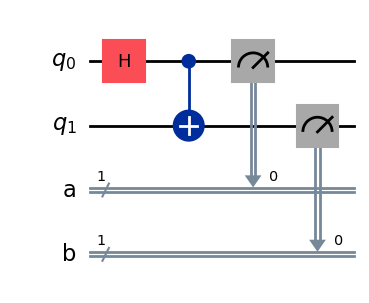

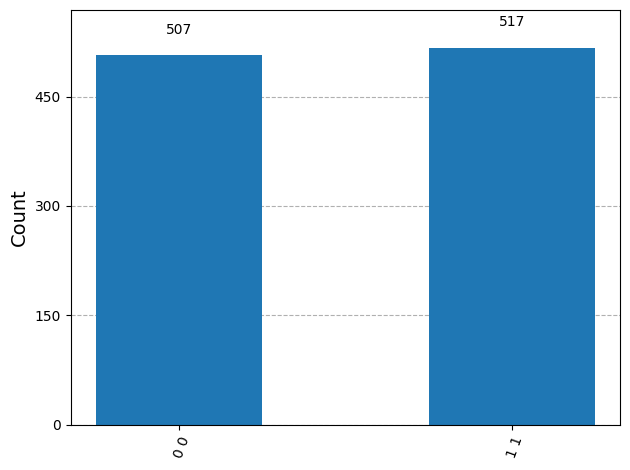

In [62]:
# output registers to place the measurement results from the quantum circuit
a = ClassicalRegister(1, 'a')
b = ClassicalRegister(1, 'b')

# note that this is the phi+ bell state
qc = QuantumCircuit(2)
qc.add_register(a)
qc.add_register(b)

qc.h(0)
qc.cx(0, 1)
qc.measure(qubit=0, cbit=a)
qc.measure(qubit=1, cbit=b)
display(qc.draw("mpl"))

from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()
job = simulator.run(qc, shots=1024)
display(plot_histogram(job.result().get_counts()))